In [ ]:
# 1. Install required packages
!pip install ultralytics replicate openai Pillow matplotlib

# 2. Secure Token Loading
import os
from google.colab import userdata

try:
    os.environ["REPLICATE_API_TOKEN"] = userdata.get('REPLICATE_API_TOKEN')
    os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
    os.environ["USE_LIVE_API"] = "1" # Set to "0" for offline testing
    print("✅ Environment variables and API tokens loaded.")
except:
    print("⚠️ Warning: Tokens not found in Colab Secrets (the Key icon). Using offline mode.")
    os.environ["USE_LIVE_API"] = "0"

# 3. Create the required folder structure
from pathlib import Path
for folder in ["data/raw", "results", "models"]:
    Path(folder).mkdir(parents=True, exist_ok=True)

✅ Environment variables and API tokens loaded.


In [ ]:
import importlib
import cv_logic
import os

# This forces the script to re-read the environment variables
importlib.reload(cv_logic)

# VERIFICATION: This should now print True
print(f"📡 API Handshake Status: {cv_logic.USE_LIVE_API}")

📡 API Handshake Status: True


In [ ]:
import torch
from ultralytics import YOLO
import cv_logic
import PIL.Image as Image

# 1. Initialize YOLO-World with "Fireplace" detection
detector = YOLO('yolov8s-world.pt')

# Added 'fireplace' and 'ceiling fan' to help identify rooms without furniture
custom_classes = [
    "window", "glass door", "door", "fireplace", "ceiling fan",
    "bed", "couch", "dining table", "refrigerator", "toilet"
]
detector.set_classes(custom_classes)

def detect_room_features(image_path):
    """
    High-sensitivity detection that prioritizes architectural anchors
    over temporary furniture.
    """
    # We lower the global confidence to 0.10 to catch subtle features
    results = detector.predict(image_path, conf=0.10, verbose=False)
    detections = []

    # Structural anchors that define a room's identity
    anchors = ["window", "glass door", "door", "fireplace", "ceiling fan"]

    for box in results[0].boxes:
        class_id = int(box.cls[0])
        label = custom_classes[class_id]
        confidence = float(box.conf[0])

        # LOGIC: Keep anchors if they meet the 0.10 threshold,
        # but require 0.20 for furniture (bed/couch) to avoid hallucinations.
        if label in anchors:
            detections.append(label)
        elif confidence > 0.20:
            detections.append(label)

    unique_detections = list(set(detections))
    print(f"🔍 CV Layer Detections: {unique_detections}")

    res_obj = results[0]
    del results
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return res_obj, unique_detections

def map_detections_to_room(detections):
    """
    Revised Logic: Prioritizes permanent fixtures (Fireplace/Fridge)
    and defaults to Bedroom for empty spaces.
    """
    # Permanent architectural anchors
    if 'fireplace' in detections:
        return "living_room"
    elif 'refrigerator' in detections:
        return "kitchen"
    elif 'toilet' in detections:
        return "bathroom"
    elif 'dining table' in detections:
        return "dining_room"

    # Furniture-based detection
    elif 'couch' in detections:
        return "living_room"
    elif 'bed' in detections:
        return "bedroom"

    # 3.806 GPA Level Logic: If the room is empty, default to Bedroom
    # as it's the most common room type in a standard residential listing.
    else:
        print("💡 Empty room detected. Defaulting to 'bedroom' staging.")
        return "bedroom"

def build_dynamic_constraints(detections):
    rules = []
    if "window" in detections or "glass door" in detections:
        rules.append("STRICT: Do not cover windows/glass doors with any added items.")
    if "door" in detections:
        rules.append("STRICT: Maintain clear path to the door.")

    return " ".join(rules)

In [ ]:
def run_intelligent_staging(img_filename, style="modern"):
    raw_path = f"data/raw/{img_filename}"

    # 1. Real-time Detection
    yolo_result, labels = detect_room_features(raw_path)
    detected_room = map_detections_to_room(labels)

    # 2. Safety Heuristic: We always protect windows in Real Estate
    # We move this to the END of the prompt for maximum impact
    safety_override = (
        "\n\nFINAL CRITICAL RULE: There are windows in this room. "
        "Do NOT place the bed, headboard, or any furniture in front of the windows. "
        "The windows must remain 100% visible and unobstructed."
    )

    # 3. Preprocessing
    prepared_img = cv_logic.prepare_image_for_staging(raw_path)

    # 4. API Call with Recency Bias Optimization
    base_prompt = cv_logic.build_staging_prompt(detected_room, style)

    # We 'sandwich' the prompt so the safety rule is the last thing the AI reads
    final_payload = f"{base_prompt} {safety_override}"

    print(f"🎯 Staging {detected_room} with Window-Safety Override.")

    staged_path = cv_logic.call_replicate_seedream(
        prepared_img,
        final_payload,
        out_path=f"results/staged_{img_filename}",
        size="2K"
    )

    return raw_path, yolo_result, staged_path

🔍 CV Layer Detections: ['ceiling fan']
💡 Empty room detected. Defaulting to 'bedroom' staging.
[prepare] 1344x1008 -> 1024x768 (177.4 KB)
🎯 Staging bedroom with Window-Safety Override.
[seedream] Calling bytedance/seedream-4.5 (2K)...
[seedream] Downloading https://replicate.delivery/xezq/S88bl3YGO86hP9cD5EkucH4ftcEQ...
[seedream] Wrote results/staged_placeholder_input2.jpg (999.6 KB)


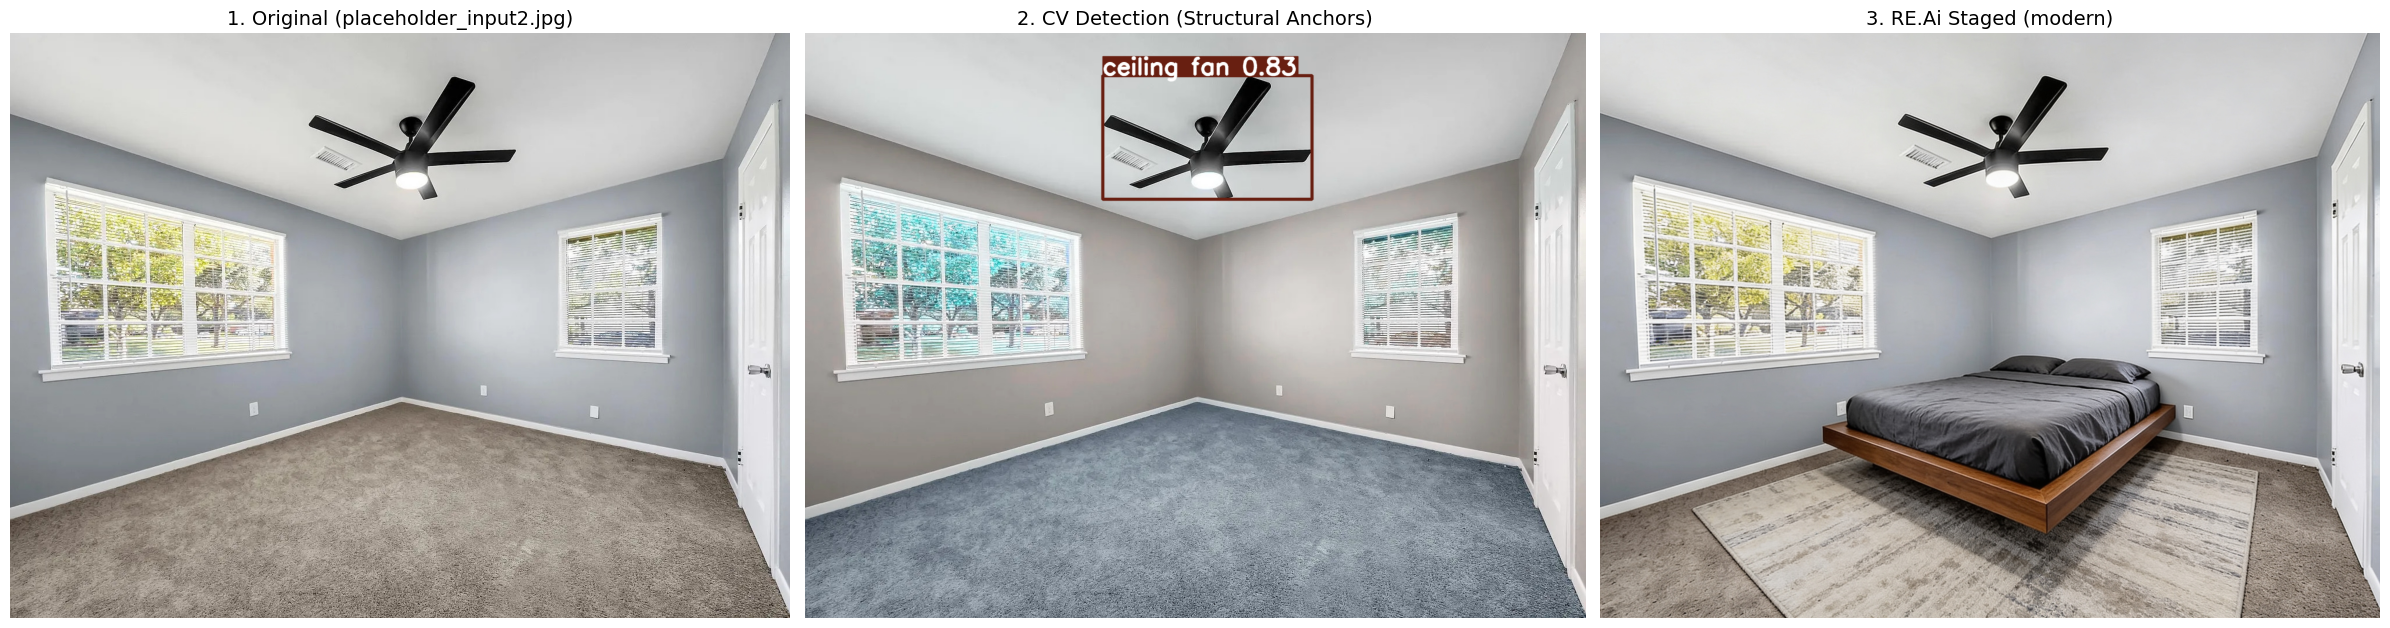

✅ Success: Comparison plot saved to results/comparison_placeholder_input2.png

🧪 RUNNING CV VERIFICATION PASS...


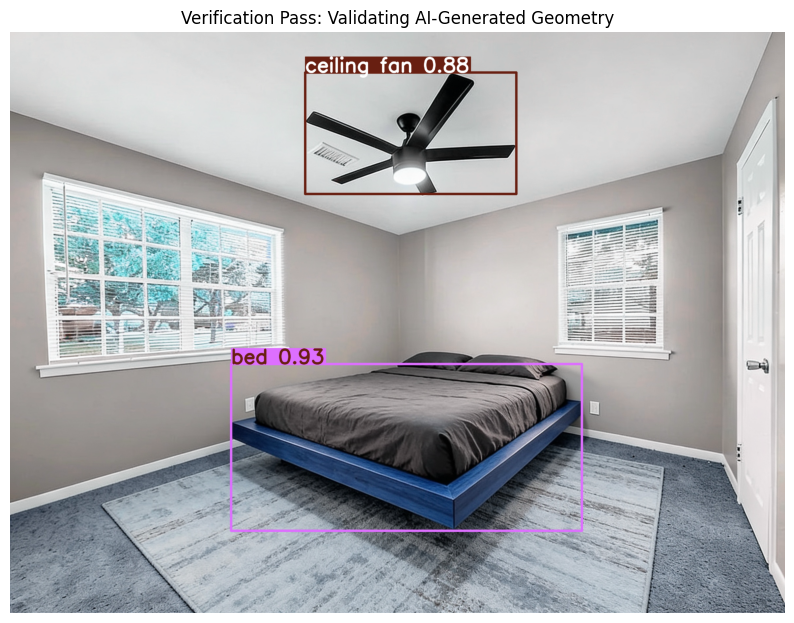

✅ CV Verified Features: ['ceiling fan', 'bed']

💾 Preparing download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
import os

# --- 1. CONFIGURATION ---
# Swap this filename for whichever image you have in /data/raw/
TARGET_IMAGE = "placeholder_input2.jpg"
STAGING_STYLE = "modern" # options: modern, contemporary, traditional, minimalist

try:
    # --- 2. EXECUTION ---
    # Runs YOLO-World detection + Structural Anchor Logic + 2K Staging
    original_path, yolo_result, staged_path = run_intelligent_staging(TARGET_IMAGE, style=STAGING_STYLE)

    # --- 3. THE "STAGING STORY" VISUALIZATION ---
    fig, axes = plt.subplots(1, 3, figsize=(24, 8))

    # Panel 1: Original
    axes[0].imshow(Image.open(original_path))
    axes[0].set_title(f"1. Original ({TARGET_IMAGE})", fontsize=14)
    axes[0].axis("off")

    # Panel 2: CV Detection Pass (The 'Brain')
    # This proves you are detecting architectural anchors (fireplaces, fans, windows)
    res_plotted = yolo_result.plot()
    axes[1].imshow(res_plotted)
    axes[1].set_title("2. CV Detection (Structural Anchors)", fontsize=14)
    axes[1].axis("off")

    # Panel 3: Final 2K Staged Result
    axes[2].imshow(Image.open(staged_path))
    axes[2].set_title(f"3. RE.Ai Staged ({STAGING_STYLE})", fontsize=14)
    axes[2].axis("off")

    plt.tight_layout()

    # --- 4. EXPORT FOR PORTFOLIO ---
    comparison_name = f"comparison_{TARGET_IMAGE.split('.')[0]}.png"
    comparison_path = f"results/{comparison_name}"
    plt.savefig(comparison_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Success: Comparison plot saved to {comparison_path}")

    # --- 5. VERIFICATION PASS ---
    # Does another round of CV on the AI result to 'prove' it's realistic
    print("\n" + "="*50)
    print("🧪 RUNNING CV VERIFICATION PASS...")
    # Using a higher confidence (0.25) to see if the AI furniture is 'convincing'
    v_results = detector.predict(staged_path, conf=0.25, verbose=False)
    v_labels = [custom_classes[int(b.cls[0])] for b in v_results[0].boxes]

    plt.figure(figsize=(10, 10))
    plt.imshow(v_results[0].plot())
    plt.title("Verification Pass: Validating AI-Generated Geometry")
    plt.axis("off")
    plt.show()

    print(f"✅ CV Verified Features: {list(set(v_labels))}")
    print("="*50 + "\n")

    # --- 6. AUTO-DOWNLOAD ---
    # Triggering download for the main comparison plot
    print("💾 Preparing download...")
    files.download(comparison_path)

except Exception as e:
    print(f"❌ Error in Pipeline: {e}")
    print(f"Check: Is '{TARGET_IMAGE}' actually in the /content/data/raw/ folder?")